# COLTIE Immersion · Week 1 · Thursday — **LAB**
## Train a model — then catch it lying


Cells marked **▶ Build together** we do as a group; **✏️ Your turn** are yours.

## 0 · Setup ▶️  *(run this one cell)*
Loads a crash dataset where **"severe" crashes are rare** — just like wrong-way events. Don't read the generator; press play.

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

def make_crashes(n=2000, seed=1):
    g = np.random.default_rng(seed)
    speed_limit = g.choice([25,35,45,55,65,70], n)
    vehicle_speed = np.clip(speed_limit + g.normal(3,9,n), 0, None).round(0)
    is_dark = (g.random(n) < 0.38).astype(int)
    is_rain = (g.random(n) < 0.22).astype(int)
    num_vehicles = g.integers(1,5,n)
    hour = g.integers(0,24,n)
    # rare 'severe' label: more likely when dark, rainy, or very fast
    risk = 0.03 + 0.11*is_dark + 0.07*is_rain + 0.05*(vehicle_speed>65) + 0.03*(num_vehicles>2)
    severe = (g.random(n) < risk).astype(int)
    return pd.DataFrame({"vehicle_speed":vehicle_speed,"hour":hour,"is_dark":is_dark,
                         "is_rain":is_rain,"num_vehicles":num_vehicles,"severe":severe})

df = make_crashes()
print(df.shape)
print("\nHow many severe crashes?")
print(df["severe"].value_counts())
print(f"\nSevere rate: {df['severe'].mean():.1%}  <- the rare class we care about")
df.head()

(2000, 6)

How many severe crashes?
severe
0    1760
1     240
Name: count, dtype: int64

Severe rate: 12.0%  <- the rare class we care about


,vehicle_speed,hour,is_dark,is_rain,num_vehicles,severe
0,41.0,6,0,0,3,0
1,49.0,16,0,0,4,0
2,76.0,6,1,0,2,1
3,75.0,23,1,1,2,0
4,38.0,9,0,0,1,0


## 1 · Features and labels ▶️
**Features** = the inputs the model gets. **Label** = the answer it must predict (`severe`).

In [ ]:
features = ["vehicle_speed","hour","is_dark","is_rain","num_vehicles"]
X = df[features]      # the inputs
y = df["severe"]      # the answer (0 = not severe, 1 = severe)
print("X shape:", X.shape, " | y shape:", y.shape)

X shape: (2000, 5)  | y shape: (2000,)


## 2 · Split, then fit ▶️
Hold out 20% as a **test set** the model never sees while training. `stratify=y` keeps the same rare-class rate in both halves.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

model = DecisionTreeClassifier(max_depth=4, random_state=0)
model.fit(X_train, y_train)      # <- this is "learning"
print("Model trained.")

train: 1600  test: 400
Model trained.


## 3 · The accuracy trap ▶️
Let's check accuracy — and compare against a **lazy baseline** that *always* predicts "not severe."

In [ ]:
pred = model.predict(X_test)
tree_acc = accuracy_score(y_test, pred)

# the lazy baseline from the lecture: always guess the majority class
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))

print(f"Decision tree accuracy : {tree_acc:.1%}")
print(f"'Always say no' accuracy: {dummy_acc:.1%}   <-- this model catches ZERO severe crashes!")

Decision tree accuracy : 88.0%
'Always say no' accuracy: 88.0%   <-- this model catches ZERO severe crashes!


**Pause.** The lazy model that never predicts 'severe' still scores in the 90s. So a high accuracy number, by itself, tells us almost nothing. Let's look closer.

## 4 · The real story — confusion matrix & recall ▶️

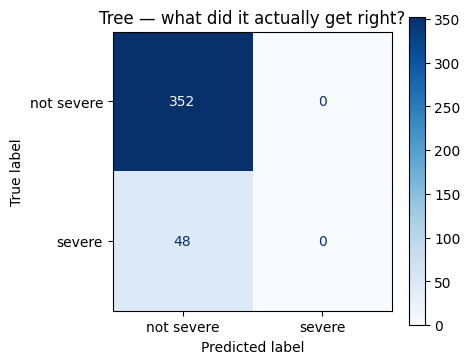

              precision    recall  f1-score   support

  not severe       0.88      1.00      0.94       352
      severe       0.00      0.00      0.00        48

    accuracy                           0.88       400
   macro avg       0.44      0.50      0.47       400
weighted avg       0.77      0.88      0.82       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
fig, ax = plt.subplots(figsize=(4.5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["not severe","severe"], cmap="Blues", ax=ax)
ax.set_title("Tree — what did it actually get right?")
plt.show()

print(classification_report(y_test, pred, target_names=["not severe","severe"]))

**Read the `severe` row.** Accuracy looked great, but look at **recall** for the severe class — that's the fraction of *real* severe crashes the model actually caught. The rest (the **FN** cell — bottom-left of the matrix) are misses. For a safety system, those misses are the whole ballgame.

## 5 · Why? Read the tree ▶️
A decision tree is glass-box — you can see exactly what it learned.

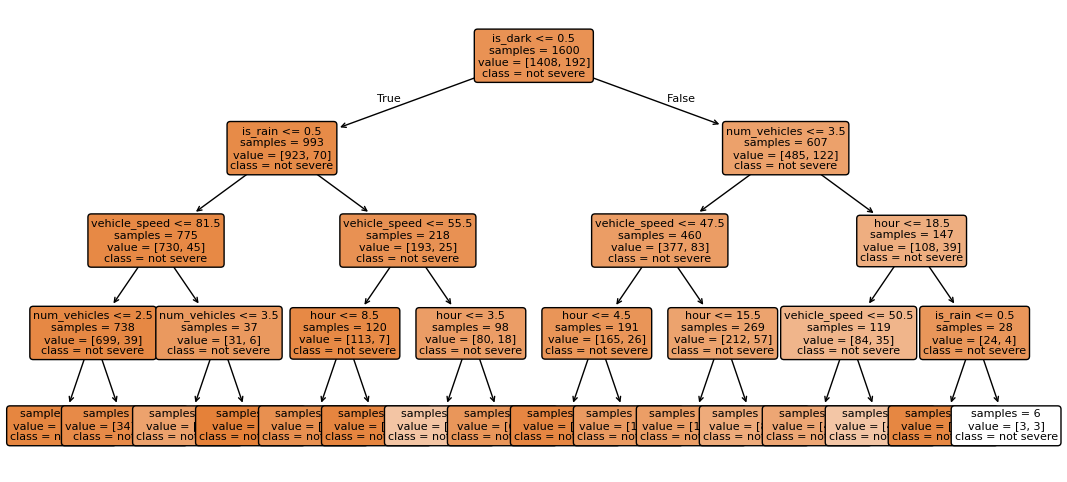

In [ ]:
fig, ax = plt.subplots(figsize=(13,6))
plot_tree(model, feature_names=features, class_names=["not severe","severe"],
          filled=True, rounded=True, impurity=False, fontsize=8, ax=ax)
plt.show()

## 6 · ✏️ Your turn — boost recall
Tell the tree to take the rare class more seriously with `class_weight="balanced"`. Run it, then compare the **severe recall** to before. What happens to the false alarms (the FP cell)?

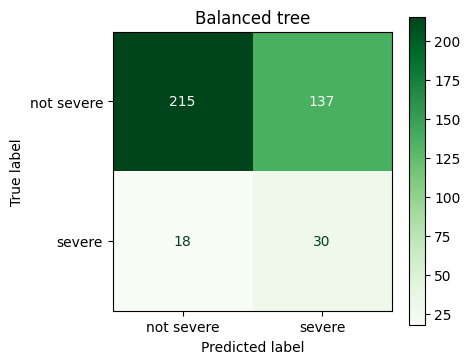

              precision    recall  f1-score   support

  not severe       0.92      0.61      0.74       352
      severe       0.18      0.62      0.28        48

    accuracy                           0.61       400
   macro avg       0.55      0.62      0.51       400
weighted avg       0.83      0.61      0.68       400



In [ ]:
# ✏️ Your turn
model2 = DecisionTreeClassifier(max_depth=4, random_state=0, class_weight="balanced")
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

fig, ax = plt.subplots(figsize=(4.5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred2, display_labels=["not severe","severe"], cmap="Greens", ax=ax)
ax.set_title("Balanced tree")
plt.show()
print(classification_report(y_test, pred2, target_names=["not severe","severe"]))

**The trade-off.** Recall on `severe` should jump up — we now catch many more real cases — but precision usually drops (more false alarms), and overall accuracy may even fall. **That's the point:** you tune the model toward the kind of mistake that's cheaper for *your* problem. For wrong-way, catching real events (recall) is worth a few false alarms.

## 7 · A fairer score — cross-validation ▶️
One split can be lucky. 5-fold cross-validation trains 5 times on different splits and averages the **F1** score (which balances precision & recall).

In [ ]:
scores = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=0, class_weight="balanced"),
    X, y, cv=5, scoring="f1")
print("F1 on each of the 5 folds:", np.round(scores, 3))
print(f"Average F1: {scores.mean():.3f}  (±{scores.std():.3f})")

F1 on each of the 5 folds: [0.295 0.251 0.271 0.291 0.268]
Average F1: 0.275  (±0.016)


## 8 · Your findings ✍️
In **three sentences**:
1. What was the tree's **accuracy**, and what was its **recall** on severe crashes? Why are they so different?
2. What did `class_weight="balanced"` change — and what did it cost?
3. If this were a real wrong-way detector, which metric would you report to your boss, and why?


In [ ]:
findings = """
1. Accuracy vs recall: The original tree's accuracy is 0.88 while the severe-recall is 0.00. This is because the model never \npredicted for the crash to be severe.
2. What 'balanced' changed (and cost): The change to 'balanced' allows for more severe crashes to be caught, but also results \nin more false positives.
3. Metric I'd report, and why: I would report the severe-recall because the most important aspect is if a crash is severe, \nas this can impact the fate of one's life.
"""
print(findings)


1. Accuracy vs recall: The original tree's accuracy is 0.88 while the severe-recall is 0.00. This is because the model never 
predicted for the crash to be severe.
2. What 'balanced' changed (and cost): The change to 'balanced' allows for more severe crashes to be caught, but also results 
in more false positives.
3. Metric I'd report, and why: I would report the severe-recall because the most important aspect is if a crash is severe, 
as this can impact the fate of one's life.



---
## Homework
1. **Change `max_depth`** to 2, then to 12. How do accuracy and severe-recall move? Which depth overfits?

2. **Write 2–3 sentences**: which single model + metric you'd trust for catching rare severe crashes, and why.

3. Train 2 new models of your choice and compare the results.


---
## Completed Homework:

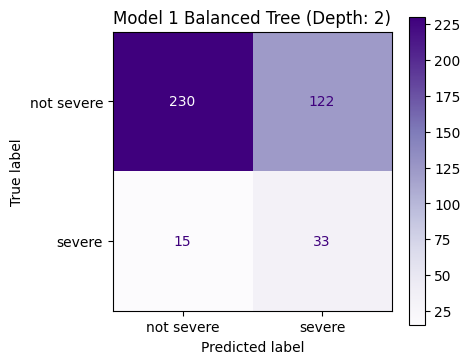

              precision    recall  f1-score   support

  not severe       0.94      0.65      0.77       352
      severe       0.21      0.69      0.33        48

    accuracy                           0.66       400
   macro avg       0.58      0.67      0.55       400
weighted avg       0.85      0.66      0.72       400



In [ ]:
depth_2_model = DecisionTreeClassifier(max_depth=2, random_state=0, class_weight="balanced")
depth_2_model.fit(X_train, y_train)
pred = depth_2_model.predict(X_test)

fig, ax = plt.subplots(figsize=(4.5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["not severe","severe"], cmap="Purples", ax=ax)
ax.set_title("Model 1 Balanced Tree (Depth: 2)")
plt.show()
print(classification_report(y_test, pred, target_names=["not severe","severe"]))

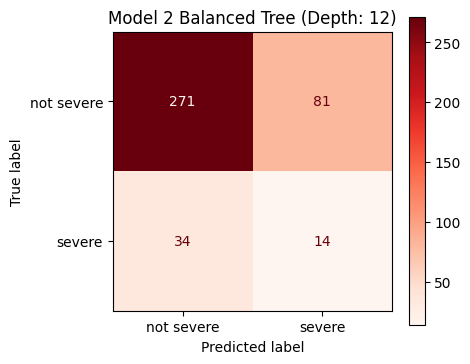

              precision    recall  f1-score   support

  not severe       0.89      0.77      0.82       352
      severe       0.15      0.29      0.20        48

    accuracy                           0.71       400
   macro avg       0.52      0.53      0.51       400
weighted avg       0.80      0.71      0.75       400



In [ ]:
depth_12_model = DecisionTreeClassifier(max_depth=12, random_state=0, class_weight="balanced")
depth_12_model.fit(X_train, y_train)
pred = depth_12_model.predict(X_test)

fig, ax = plt.subplots(figsize=(4.5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["not severe","severe"], cmap="Reds", ax=ax)
ax.set_title("Model 2 Balanced Tree (Depth: 12)")
plt.show()
print(classification_report(y_test, pred, target_names=["not severe","severe"]))

In [ ]:
homework_findings = """
1. The tree with a depth of 2 has an accuracy of 0.66 and a severe-recall of 0.69, while the tree with a depth of 12 has an accuracy \nof 0.71 and a severe-recall of 0.29. The model with a depth of 12 overfits and focuses too much on the training data.
2. The single model that I would trust the most is the balanced tree with a maximum-depth of 4 because it has a greater emphasis on \nrare and severe crashes, and has a greater severe-recall compared to other models.
3. The second model (depth 12) has a greater accuracy than the first model (depth 2), but the first model has a significantly \ngreater severe-recall.
"""
print(homework_findings)


1. The tree with a depth of 2 has an accuracy of 0.66 and a severe-recall of 0.69, while the tree with a depth of 12 has an accuracy 
of 0.71 and a severe-recall of 0.29. The model with a depth of 12 overfits and focuses too much on the training data.
2. The single model that I would trust the most is the balanced tree with a maximum-depth of 4 because it has a greater emphasis on 
rare and severe crashes, and has a greater severe-recall compared to other models. 
3. The second model (depth 12) has a greater accuracy than the first model (depth 2), but the first model has a significantly 
greater severe-recall.

